Import Library

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

 LOAD & EXPLORATORY DATA ANALYSIS (EDA)

In [3]:
df = pd.read_csv('citrus.csv')

In [4]:
print("--- 5 Data Teratas ---")
print(df.head())
print("\n--- Informasi Dataset ---")
print(df.info())
print("\n--- Statistik Deskriptif ---")
print(df.describe())

--- 5 Data Teratas ---
     name  diameter  weight  red  green  blue
0  orange      2.96   86.76  172     85     2
1  orange      3.91   88.05  166     78     3
2  orange      4.42   95.17  156     81     2
3  orange      4.47   95.60  163     81     4
4  orange      4.48   95.76  161     72     9

--- Informasi Dataset ---
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   name      10000 non-null  str    
 1   diameter  10000 non-null  float64
 2   weight    10000 non-null  float64
 3   red       10000 non-null  int64  
 4   green     10000 non-null  int64  
 5   blue      10000 non-null  int64  
dtypes: float64(2), int64(3), str(1)
memory usage: 468.9 KB
None

--- Statistik Deskriptif ---
           diameter        weight           red         green          blue
count  10000.000000  10000.000000  10000.000000  10000.000000  10000.000000
mean       9.975685

C:\Users\RANURA\AppData\Local\Temp\ipykernel_14252\456902492.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='name', data=df, palette='Set2')


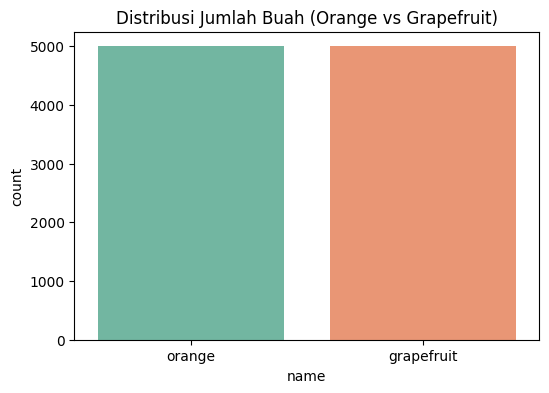

In [5]:
# Visualisasi Distribusi Target
plt.figure(figsize=(6,4))
sns.countplot(x='name', data=df, palette='Set2')
plt.title('Distribusi Jumlah Buah (Orange vs Grapefruit)')
plt.show()

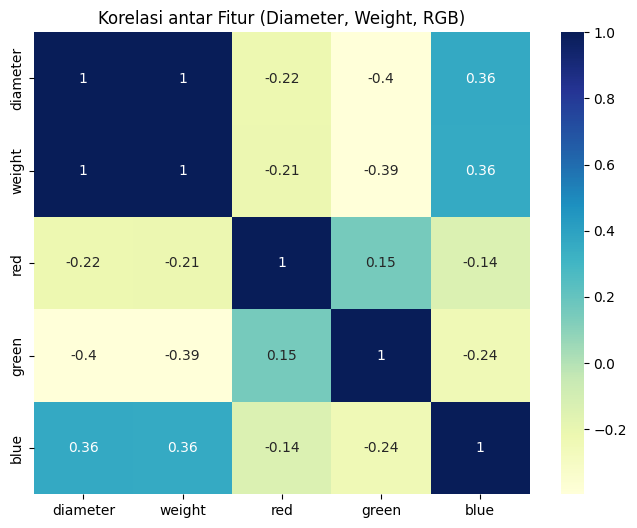

In [6]:
# Visualisasi Korelasi antar fitur
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='YlGnBu')
plt.title('Korelasi antar Fitur (Diameter, Weight, RGB)')
plt.show()

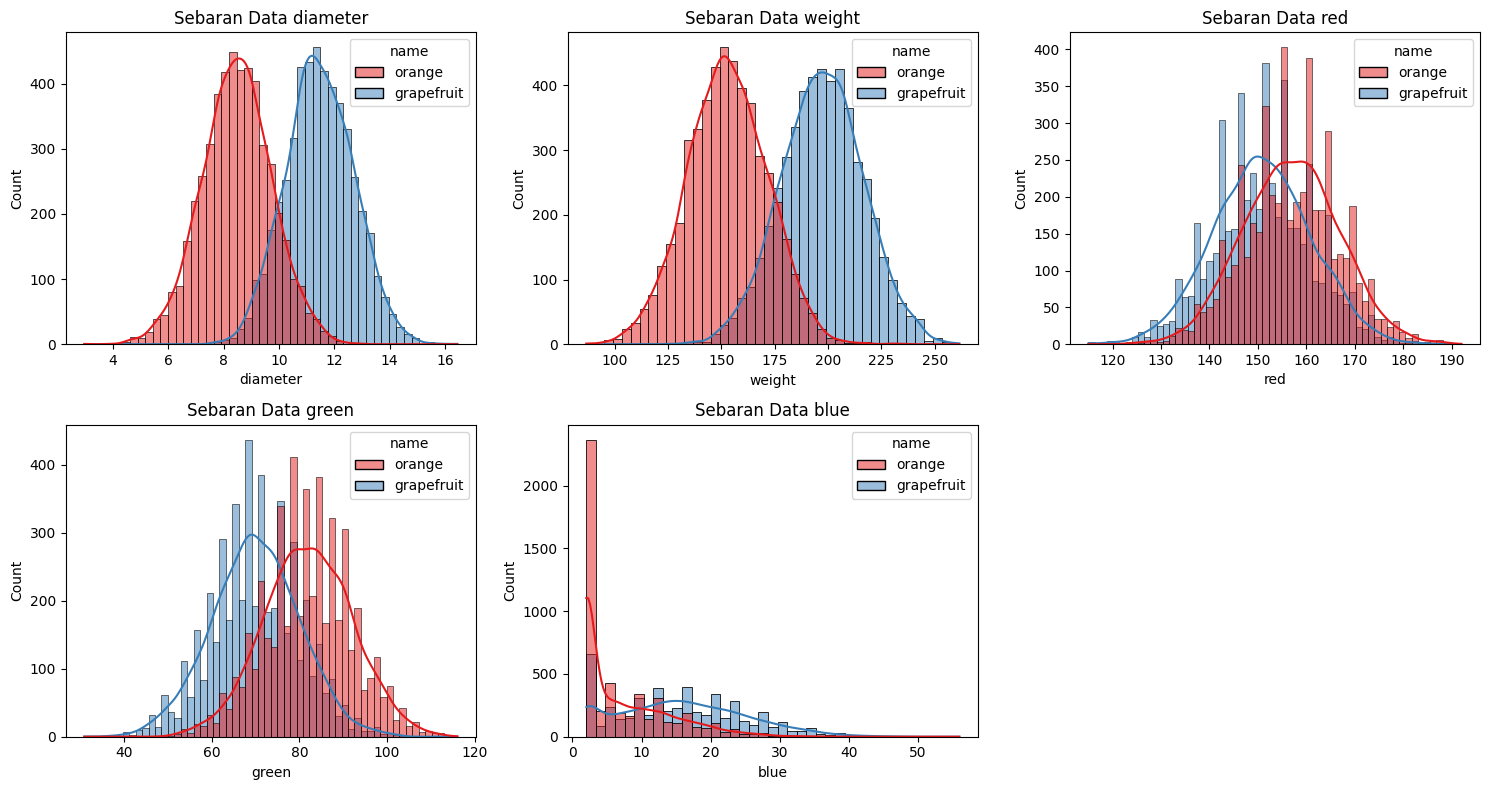

In [7]:
import math

# Identifikasi kolom numerik (kecuali target 'name')
kolom_numerik = ['diameter', 'weight', 'red', 'green', 'blue']

# Menentukan Jumlah Baris dan Kolom
jumlah_kolom = 3
jumlah_baris = math.ceil(len(kolom_numerik) / jumlah_kolom)

# Membuat Canvas
fig, ax = plt.subplots(jumlah_baris, jumlah_kolom, figsize=(15, 8))
ax = ax.flatten()

# Looping Visualisasi Histogram
for i, kolom in enumerate(kolom_numerik): 
    sns.histplot(data=df, x=kolom, ax=ax[i], kde=True, hue='name', palette='Set1')
    ax[i].set_title(f'Sebaran Data {kolom}')

# Menghapus Sisa Plot yang Kosong
for i in range(len(kolom_numerik), len(ax)): 
    fig.delaxes(ax[i])

# Menampilkan Visualisasi
plt.tight_layout()
plt.show()

PREPROCESSING

In [8]:
# Mengubah label target menjadi angka
le = LabelEncoder()
df['name'] = le.fit_transform(df['name']) # orange=1, grapefruit=0

X = df.drop(columns=['name'])
y = df['name']

In [9]:
# Scaling (Penting untuk SVM dan Naive Bayes agar fitur seimbang)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [10]:
# Split data 80:20
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

MODELLING & EVALUATION

In [11]:
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Naive Bayes": GaussianNB(),
    "Support Vector Machine": SVC(kernel='linear', random_state=42)
}


MODEL: Decision Tree
Accuracy Score: 0.9415

Classification Report:
              precision    recall  f1-score   support

  Grapefruit       0.94      0.95      0.94       988
      Orange       0.95      0.94      0.94      1012

    accuracy                           0.94      2000
   macro avg       0.94      0.94      0.94      2000
weighted avg       0.94      0.94      0.94      2000



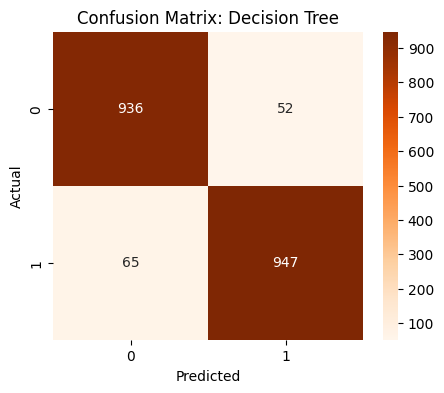


MODEL: Naive Bayes
Accuracy Score: 0.9200

Classification Report:
              precision    recall  f1-score   support

  Grapefruit       0.91      0.93      0.92       988
      Orange       0.93      0.91      0.92      1012

    accuracy                           0.92      2000
   macro avg       0.92      0.92      0.92      2000
weighted avg       0.92      0.92      0.92      2000



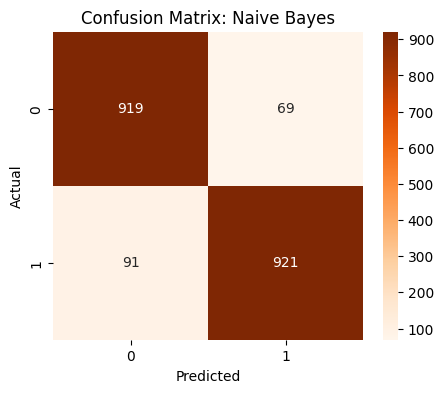


MODEL: Support Vector Machine
Accuracy Score: 0.9515

Classification Report:
              precision    recall  f1-score   support

  Grapefruit       0.93      0.98      0.95       988
      Orange       0.98      0.93      0.95      1012

    accuracy                           0.95      2000
   macro avg       0.95      0.95      0.95      2000
weighted avg       0.95      0.95      0.95      2000



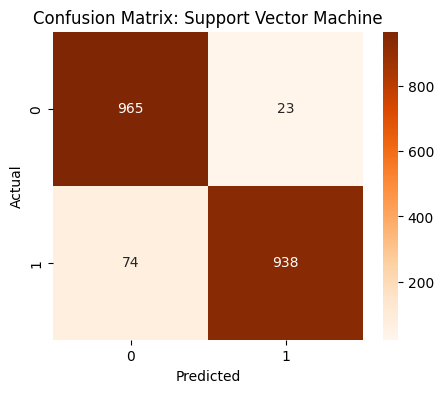

In [12]:
# Dictionary untuk menyimpan akurasi
accuracy_results = {}

# Loop untuk menjalankan setiap model
for name, model in models.items():
    # Training
    model.fit(X_train, y_train)
    
    # Prediksi
    y_pred = model.predict(X_test)
    
    # Evaluasi Akurasi
    acc = accuracy_score(y_test, y_pred)
    accuracy_results[name] = acc
    
    print(f"\n" + "="*40)
    print(f"MODEL: {name}")
    print("="*40)
    print(f"Accuracy Score: {acc:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=['Grapefruit', 'Orange']))
    
    # Confusion Matrix Visualization
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges')
    plt.title(f'Confusion Matrix: {name}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

Visualitation Tree

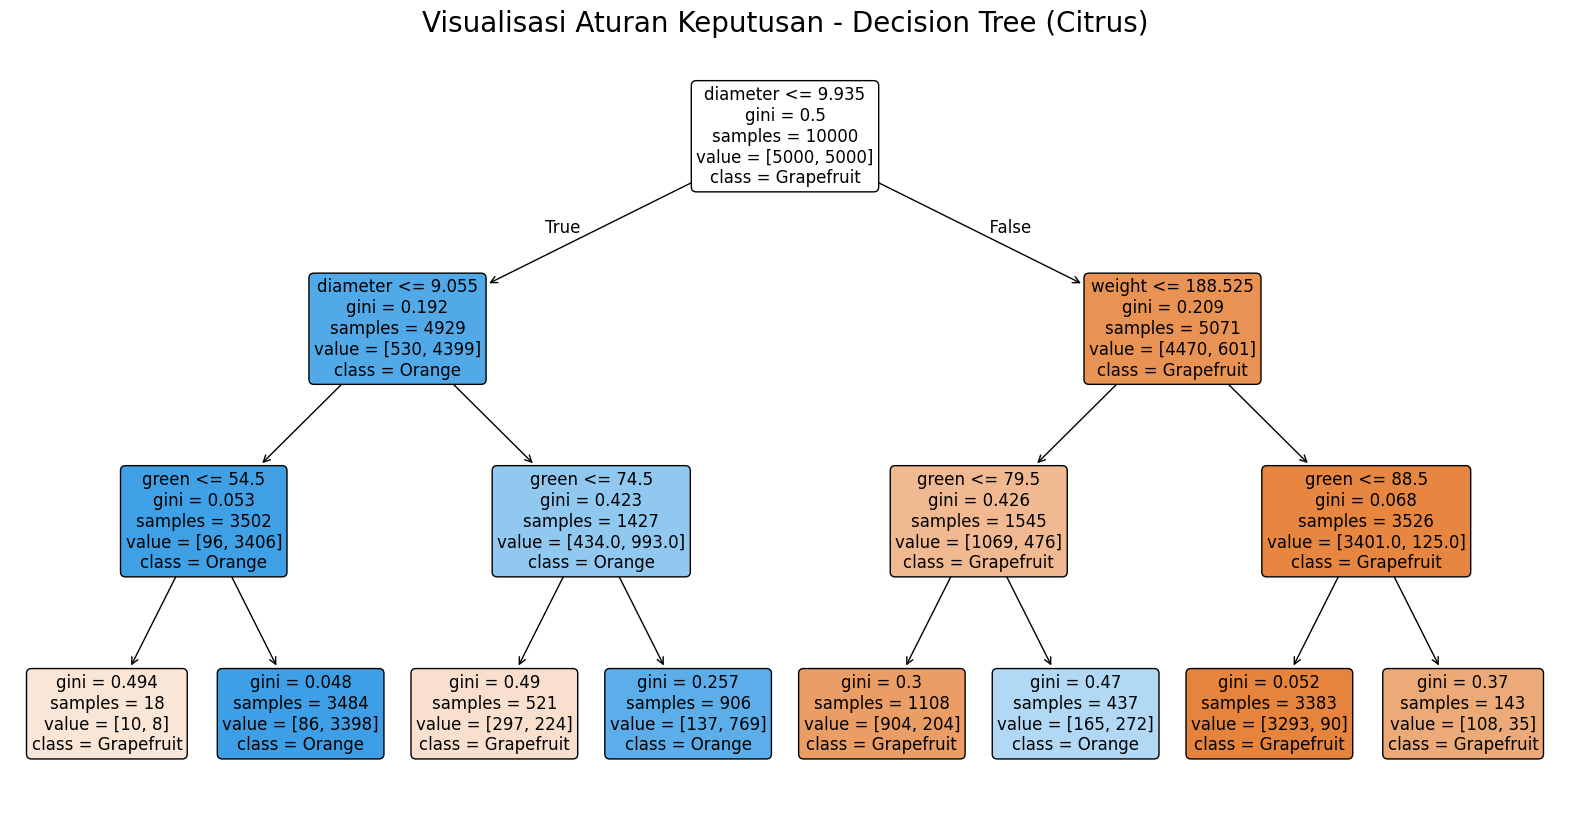

In [13]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt


dt_viz = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_viz.fit(X, y)

# Membuat canvas visualisasi
plt.figure(figsize=(20, 10))

# Fungsi untuk menggambar pohon
plot_tree(dt_viz, 
          feature_names=X.columns,  
          class_names=['Grapefruit', 'Orange'], 
          filled=True,   
          rounded=True,    
          fontsize=12)

plt.title("Visualisasi Aturan Keputusan - Decision Tree (Citrus)", fontsize=20)
plt.show()

PERBANDINGAN AKURASI AKHIR

C:\Users\RANURA\AppData\Local\Temp\ipykernel_14252\1065833918.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=model_names, y=accuracies, palette='viridis')


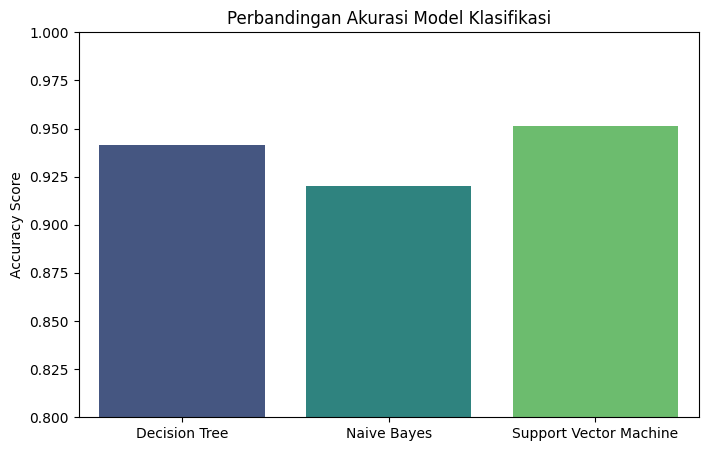


--- Ringkasan Akurasi ---
Decision Tree: 0.9415
Naive Bayes: 0.9200
Support Vector Machine: 0.9515


In [14]:
plt.figure(figsize=(8,5))
model_names = list(accuracy_results.keys())
accuracies = list(accuracy_results.values())
sns.barplot(x=model_names, y=accuracies, palette='viridis')
plt.ylim(0.8, 1.0) # Fokus pada rentang akurasi tinggi
plt.title('Perbandingan Akurasi Model Klasifikasi')
plt.ylabel('Accuracy Score')
plt.show()

print("\n--- Ringkasan Akurasi ---")
for m, a in accuracy_results.items():
    print(f"{m}: {a:.4f}")